# Entrega 3  Reducción de características y evaluación

Este cuaderno replica el baseline de clasificación y ejecuta distintos experimentos de selección/reducción de características (importancia por RandomForest, SelectKBest, PCA). Los resultados intermedios se guardan en Entrega 3/artifacts/ y los hallazgos se documentados en Entrega 3/docs/feature_reduction.md.


In [11]:
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline


In [12]:
PROJECT_ROOT = Path('.').resolve()
ENTREGA2_PATH = PROJECT_ROOT / 'Entrega 2'
ENTREGA3_PATH = PROJECT_ROOT / 'Entrega 3'
ARTIFACTS_PATH = ENTREGA3_PATH / 'artifacts'
DOCS_PATH = ENTREGA3_PATH / 'docs'

ARTIFACTS_PATH.mkdir(parents=True, exist_ok=True)
DOCS_PATH.mkdir(parents=True, exist_ok=True)

print(f"Proyecto: {PROJECT_ROOT}")
print(f"Guardando artefactos en: {ARTIFACTS_PATH}")


Proyecto: /content
Guardando artefactos en: /content/Entrega 3/artifacts


In [13]:
LANDMARKS_CSV = ENTREGA2_PATH / 'landmarks_data.csv'
SUBJECT_METADATA_CSV = ENTREGA2_PATH / 'metadata.csv'  # opcional (si existe)

if not LANDMARKS_CSV.exists():
    raise FileNotFoundError(f"No encuentro {LANDMARKS_CSV}. Asegúrate de generar/exportar el CSV desde Entrega 2.")

landmarks_df = pd.read_csv(LANDMARKS_CSV)
print(landmarks_df.shape)
landmarks_df.head()


(13035, 133)


,0_x,0_y,0_z,0_v,1_x,1_y,1_z,1_v,2_x,2_y,...,30_v,31_x,31_y,31_z,31_v,32_x,32_y,32_z,32_v,class
0,0.419056,0.181214,0.242158,0.999652,0.420217,0.167612,0.160949,0.999597,0.417675,0.167477,...,0.872379,0.277300,0.776001,0.039766,0.925620,0.385196,0.730761,0.505285,0.794547,atras
1,0.422976,0.181181,0.246730,0.999609,0.421860,0.167688,0.164632,0.999549,0.418480,0.167546,...,0.875385,0.277288,0.765799,0.047610,0.925866,0.385064,0.729794,0.505651,0.796320,atras
2,0.433355,0.180700,0.251780,0.999608,0.429510,0.167638,0.168614,0.999542,0.424477,0.167509,...,0.880771,0.274615,0.746793,0.252565,0.922207,0.388084,0.727026,0.529869,0.796374,atras
3,0.440365,0.179886,0.273644,0.999619,0.434974,0.167462,0.192190,0.999548,0.429029,0.167316,...,0.887158,0.268603,0.740661,0.260996,0.919406,0.392293,0.727191,0.526102,0.797088,atras
4,0.442957,0.179591,0.274256,0.999634,0.436698,0.167356,0.192897,0.999560,0.430557,0.167191,...,0.892730,0.261259,0.723440,0.322839,0.911464,0.401974,0.725774,0.529382,0.789858,atras


In [16]:
   landmarks_df['class'].value_counts()

,count
class,
girar,3536
adelante,3417
atras,3384
sentarse,1387
pararse,1311


In [17]:
if SUBJECT_METADATA_CSV.exists():
    subject_df = pd.read_csv(SUBJECT_METADATA_CSV)
    print(f"Metadata cargada con {subject_df.shape[0]} filas")
    subject_df.head()
else:
    subject_df = None
    print("No se encontró metadata de sujetos; los experimentos usarán sólo etiquetas de clase.")


No se encontró metadata de sujetos; los experimentos usarán sólo etiquetas de clase.


In [18]:
RANDOM_STATE = 42
TEST_SIZE = 0.2

label_encoder = LabelEncoder()

def prepare_data(df):
    X = df.drop(columns=['class'])
    y = df['class']
    y_encoded = label_encoder.fit_transform(y)
    feature_names = X.columns.tolist()
    return X, y, y_encoded, feature_names


def split_data(X, y_encoded, test_size=TEST_SIZE, random_state=RANDOM_STATE):
    return train_test_split(
        X, y_encoded,
        test_size=test_size,
        stratify=y_encoded,
        random_state=random_state
    )


def evaluate_classifier(classifier, X_train, X_test, y_train, y_test, feature_subset=None, run_name="baseline"):
    steps = [('imputer', SimpleImputer(strategy='mean'))]
    needs_scaling = not isinstance(classifier, RandomForestClassifier)
    if needs_scaling:
        steps.append(('scaler', StandardScaler()))
    steps.append(('classifier', classifier))

    pipeline = Pipeline(steps)

    if feature_subset is not None:
        X_train = X_train[feature_subset]
        X_test = X_test[feature_subset]

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    report = classification_report(y_test, y_pred, target_names=label_encoder.classes_, output_dict=True)
    cm = confusion_matrix(y_test, y_pred)

    metrics = {
        'run': run_name,
        'accuracy': acc,
        'macro_f1': macro_f1,
        'classifier': type(classifier).__name__,
        'n_features': X_train.shape[1]
    }

    return {
        'pipeline': pipeline,
        'metrics': metrics,
        'report': report,
        'confusion_matrix': cm,
        'y_pred': y_pred
    }


In [19]:
X, y, y_encoded, feature_names = prepare_data(landmarks_df)
X_train, X_test, y_train, y_test = split_data(X, y_encoded)

print(f"Total muestras: {X.shape[0]}")
print(f"Features iniciales: {len(feature_names)}")
print(pd.Series(label_encoder.classes_).reset_index().rename(columns={'index': 'encoded_label', 0: 'class'}))


Total muestras: 13035
Features iniciales: 132
   encoded_label     class
0              0  adelante
1              1     atras
2              2     girar
3              3   pararse
4              4  sentarse


In [20]:
results = []

rf_baseline = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_leaf=1,
    class_weight='balanced',
    n_jobs=-1,
    random_state=RANDOM_STATE
)

baseline_output = evaluate_classifier(rf_baseline, X_train.copy(), X_test.copy(), y_train, y_test, run_name='baseline_all_features')
results.append(baseline_output['metrics'])

print(json.dumps(baseline_output['metrics'], indent=2))


{
  "run": "baseline_all_features",
  "accuracy": 0.982355197545071,
  "macro_f1": 0.9853228801099163,
  "classifier": "RandomForestClassifier",
  "n_features": 132
}


Reporte baseline guardado en: /content/Entrega 3/artifacts/baseline_classification_report.csv


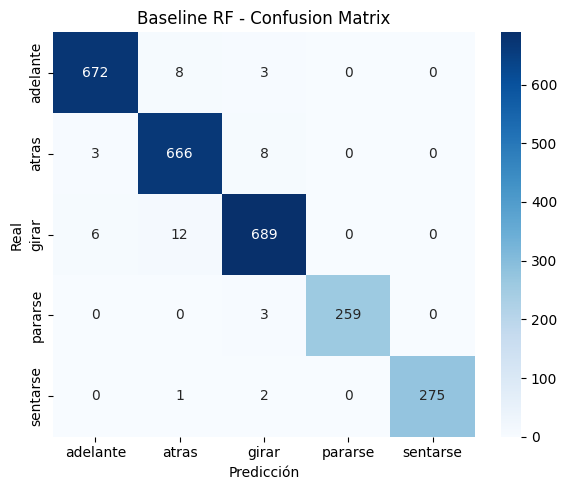

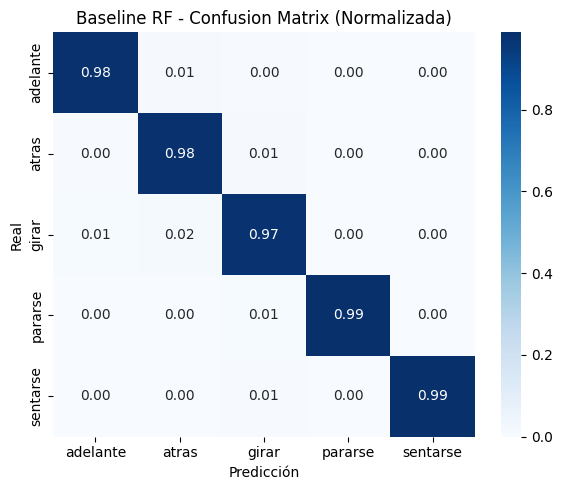

In [21]:
def plot_confusion_matrix(cm, classes, title, normalize=False):
    cm_to_plot = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] if normalize else cm
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_to_plot, annot=True, fmt='.2f' if normalize else 'd', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.title(title)
    plt.tight_layout()

plot_confusion_matrix(baseline_output['confusion_matrix'], label_encoder.classes_, 'Baseline RF - Confusion Matrix')
plot_confusion_matrix(baseline_output['confusion_matrix'], label_encoder.classes_, 'Baseline RF - Confusion Matrix (Normalizada)', normalize=True)

baseline_report_df = pd.DataFrame(baseline_output['report']).transpose()
baseline_report_path = ARTIFACTS_PATH / 'baseline_classification_report.csv'
baseline_report_df.to_csv(baseline_report_path)
print(f"Reporte baseline guardado en: {baseline_report_path}")


Guardadas importancias en /content/Entrega 3/artifacts/rf_feature_importances.csv


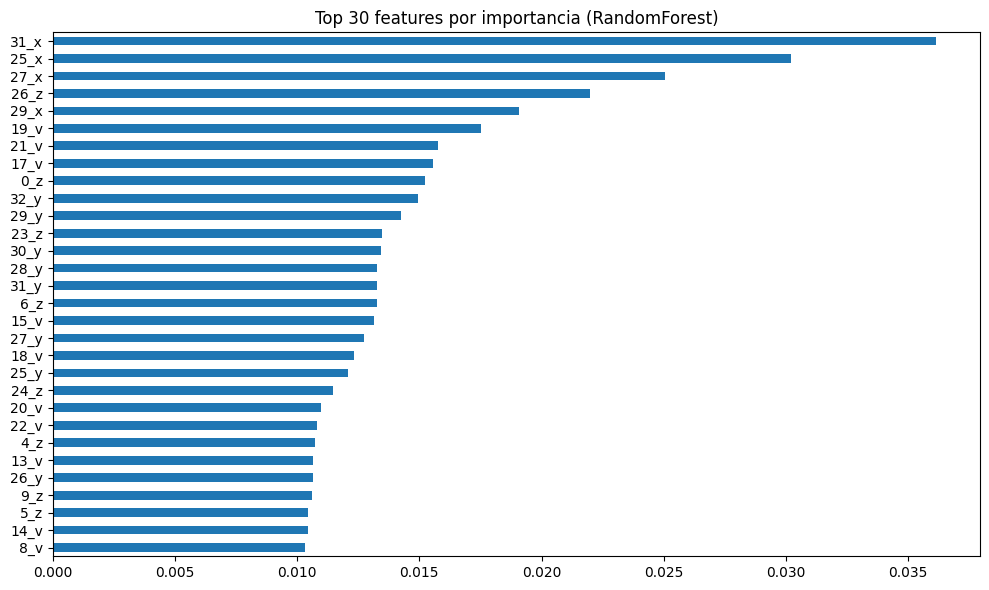

,0
31_x,0.036129
25_x,0.030194
27_x,0.025052
26_z,0.021966
29_x,0.019073
19_v,0.017507
21_v,0.015757
17_v,0.015575
0_z,0.015248
32_y,0.014945


In [22]:
rf_model = baseline_output['pipeline'].named_steps['classifier']
importances = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=False)

importance_path = ARTIFACTS_PATH / 'rf_feature_importances.csv'
importances.to_csv(importance_path, header=['importance'])
print(f"Guardadas importancias en {importance_path}")

plt.figure(figsize=(10, 6))
importances.head(30).sort_values().plot(kind='barh')
plt.title('Top 30 features por importancia (RandomForest)')
plt.tight_layout()
plt.show()

importances.head(10)


In [23]:
TOP_FEATURE_COUNTS = [20, 40, 60, 80, 100]

feature_subset_results = []

for k in TOP_FEATURE_COUNTS:
    top_features = importances.head(k).index.tolist()
    run_name = f'rf_top_{k}_importances'
    output = evaluate_classifier(
        RandomForestClassifier(
            n_estimators=400,
            max_depth=None,
            min_samples_leaf=1,
            class_weight='balanced',
            n_jobs=-1,
            random_state=RANDOM_STATE
        ),
        X_train.copy(),
        X_test.copy(),
        y_train,
        y_test,
        feature_subset=top_features,
        run_name=run_name
    )
    results.append(output['metrics'])
    feature_subset_results.append({
        'k': k,
        'run_name': run_name,
        'metrics': output['metrics']
    })
    print(run_name, '-> accuracy:', output['metrics']['accuracy'], 'macro_f1:', output['metrics']['macro_f1'])

feature_subset_df = pd.DataFrame([
    {
        'k': r['k'],
        'accuracy': r['metrics']['accuracy'],
        'macro_f1': r['metrics']['macro_f1']
    }
    for r in feature_subset_results
])
feature_subset_df


rf_top_20_importances -> accuracy: 0.9666283084004603 macro_f1: 0.9730423479947522
rf_top_40_importances -> accuracy: 0.9766014576141159 macro_f1: 0.9807568926054622
rf_top_60_importances -> accuracy: 0.9796701189106253 macro_f1: 0.9833048444718123
rf_top_80_importances -> accuracy: 0.9808208668968162 macro_f1: 0.9841697976080264
rf_top_100_importances -> accuracy: 0.98120444955888 macro_f1: 0.9842151370411619


,k,accuracy,macro_f1
0,20,0.966628,0.973042
1,40,0.976601,0.980757
2,60,0.979670,0.983305
3,80,0.980821,0.984170
4,100,0.981204,0.984215


Resultados top-k guardados en /content/Entrega 3/artifacts/rf_topk_importance_results.csv


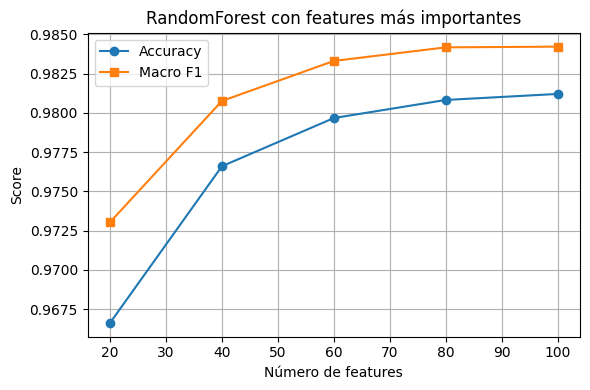

In [24]:
subset_results_path = ARTIFACTS_PATH / 'rf_topk_importance_results.csv'
feature_subset_df.to_csv(subset_results_path, index=False)
print(f"Resultados top-k guardados en {subset_results_path}")

plt.figure(figsize=(6, 4))
plt.plot(feature_subset_df['k'], feature_subset_df['accuracy'], marker='o', label='Accuracy')
plt.plot(feature_subset_df['k'], feature_subset_df['macro_f1'], marker='s', label='Macro F1')
plt.ylabel('Score')
plt.xlabel('Número de features')
plt.title('RandomForest con features más importantes')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [25]:
# Preparar versiones imputadas para selecciones estadísticas
imputer = SimpleImputer(strategy='mean')
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_imputed = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns, index=X_test.index)



In [26]:
def evaluate_selectkbest(score_func, k, name_prefix):
    selector = SelectKBest(score_func=score_func, k=k)
    selector.fit(X_train_imputed, y_train)
    support = selector.get_support()
    selected_features = X_train_imputed.columns[support].tolist()

    svm_clf = make_pipeline(
        StandardScaler(),
        SVC(kernel='rbf', C=10, gamma=0.01, class_weight='balanced', random_state=RANDOM_STATE)
    )

    svm_clf.fit(X_train_imputed[selected_features], y_train)
    y_pred = svm_clf.predict(X_test_imputed[selected_features])

    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro')

    run_name = f"{name_prefix}_k{k}"
    results.append({
        'run': run_name,
        'accuracy': acc,
        'macro_f1': macro_f1,
        'classifier': 'SVC',
        'n_features': k
    })

    return {
        'run_name': run_name,
        'accuracy': acc,
        'macro_f1': macro_f1,
        'selected_features': selected_features,
        'y_pred': y_pred
    }


In [29]:
from sklearn.svm import SVC
SELECT_K_VALUES = [20, 40, 60, 80, 100]

anova_results = []
mi_results = []

for k in SELECT_K_VALUES:
    anova_output = evaluate_selectkbest(f_classif, k, 'anova')
    anova_results.append(anova_output)
    print(f"ANOVA k={k} -> acc {anova_output['accuracy']:.4f}, macro_f1 {anova_output['macro_f1']:.4f}")

for k in SELECT_K_VALUES:
    mi_output = evaluate_selectkbest(mutual_info_classif, k, 'mutual_info')
    mi_results.append(mi_output)
    print(f"MutualInfo k={k} -> acc {mi_output['accuracy']:.4f}, macro_f1 {mi_output['macro_f1']:.4f}")

anova_df = pd.DataFrame(anova_results)
mi_df = pd.DataFrame(mi_results)

anova_df[['run_name', 'accuracy', 'macro_f1']], mi_df[['run_name', 'accuracy', 'macro_f1']]


ANOVA k=20 -> acc 0.7871, macro_f1 0.7668
ANOVA k=40 -> acc 0.8895, macro_f1 0.8952
ANOVA k=60 -> acc 0.9340, macro_f1 0.9406
ANOVA k=80 -> acc 0.9689, macro_f1 0.9736
ANOVA k=100 -> acc 0.9789, macro_f1 0.9816
MutualInfo k=20 -> acc 0.7833, macro_f1 0.7709
MutualInfo k=40 -> acc 0.8776, macro_f1 0.8739
MutualInfo k=60 -> acc 0.9313, macro_f1 0.9387
MutualInfo k=80 -> acc 0.9662, macro_f1 0.9702
MutualInfo k=100 -> acc 0.9793, macro_f1 0.9828


(     run_name  accuracy  macro_f1
 0   anova_k20  0.787112  0.766811
 1   anova_k40  0.889528  0.895194
 2   anova_k60  0.934024  0.940634
 3   anova_k80  0.968930  0.973611
 4  anova_k100  0.978903  0.981632,
            run_name  accuracy  macro_f1
 0   mutual_info_k20  0.783276  0.770921
 1   mutual_info_k40  0.877637  0.873934
 2   mutual_info_k60  0.931339  0.938693
 3   mutual_info_k80  0.966245  0.970201
 4  mutual_info_k100  0.979287  0.982824)

In [30]:
anova_features_path = ARTIFACTS_PATH / 'anova_selected_features.json'
mi_features_path = ARTIFACTS_PATH / 'mutual_info_selected_features.json'

with open(anova_features_path, 'w') as fp:
    json.dump({r['run_name']: r['selected_features'] for r in anova_results}, fp, indent=2)

with open(mi_features_path, 'w') as fp:
    json.dump({r['run_name']: r['selected_features'] for r in mi_results}, fp, indent=2)

print(f"Guardadas listas de features ANOVA en {anova_features_path}")
print(f"Guardadas listas de features Mutual Info en {mi_features_path}")

anova_summary_path = ARTIFACTS_PATH / 'anova_results.csv'
mi_summary_path = ARTIFACTS_PATH / 'mutual_info_results.csv'

anova_df[['run_name', 'accuracy', 'macro_f1']].to_csv(anova_summary_path, index=False)
mi_df[['run_name', 'accuracy', 'macro_f1']].to_csv(mi_summary_path, index=False)

print(f"Tablas de resultados guardadas en {anova_summary_path} y {mi_summary_path}")


Guardadas listas de features ANOVA en /content/Entrega 3/artifacts/anova_selected_features.json
Guardadas listas de features Mutual Info en /content/Entrega 3/artifacts/mutual_info_selected_features.json
Tablas de resultados guardadas en /content/Entrega 3/artifacts/anova_results.csv y /content/Entrega 3/artifacts/mutual_info_results.csv


In [31]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

pca_components = [10, 20, 40, 60, 80, 100]

pca_results = []

for n_comp in pca_components:
    pca = PCA(n_components=n_comp, random_state=RANDOM_STATE)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    svm_clf = SVC(kernel='rbf', C=10, gamma=0.01, class_weight='balanced', random_state=RANDOM_STATE)
    svm_clf.fit(X_train_pca, y_train)
    y_pred = svm_clf.predict(X_test_pca)

    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    explained_var = pca.explained_variance_ratio_.sum()

    run_name = f'pca_{n_comp}'
    results.append({
        'run': run_name,
        'accuracy': acc,
        'macro_f1': macro_f1,
        'classifier': 'SVC_PCA',
        'n_features': n_comp
    })

    pca_results.append({
        'run_name': run_name,
        'n_components': n_comp,
        'accuracy': acc,
        'macro_f1': macro_f1,
        'explained_variance': explained_var
    })

    print(f"PCA {n_comp} comp -> acc {acc:.4f}, macro_f1 {macro_f1:.4f}, varianza explicada {explained_var:.4f}")

pca_df = pd.DataFrame(pca_results)
pca_df


PCA 10 comp -> acc 0.9513, macro_f1 0.9499, varianza explicada 0.8954
PCA 20 comp -> acc 0.9735, macro_f1 0.9723, varianza explicada 0.9795
PCA 40 comp -> acc 0.9843, macro_f1 0.9834, varianza explicada 0.9981
PCA 60 comp -> acc 0.9877, macro_f1 0.9896, varianza explicada 0.9996
PCA 80 comp -> acc 0.9877, macro_f1 0.9896, varianza explicada 0.9999
PCA 100 comp -> acc 0.9873, macro_f1 0.9894, varianza explicada 1.0000


,run_name,n_components,accuracy,macro_f1,explained_variance
0,pca_10,10,0.951285,0.949899,0.895402
1,pca_20,20,0.973533,0.972309,0.979471
2,pca_40,40,0.984273,0.983390,0.998146
3,pca_60,60,0.987725,0.989644,0.999634
4,pca_80,80,0.987725,0.989644,0.999908
5,pca_100,100,0.987342,0.989356,0.999983


Resultados PCA guardados en /content/Entrega 3/artifacts/pca_results.csv


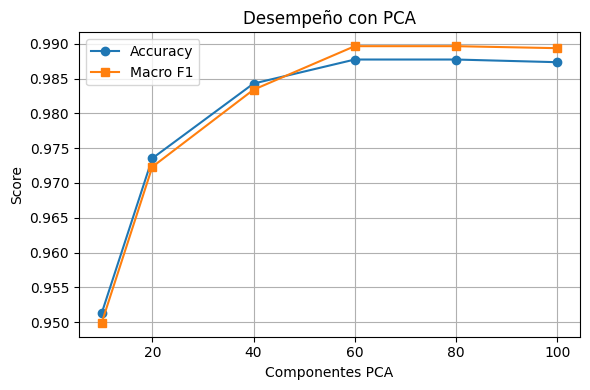

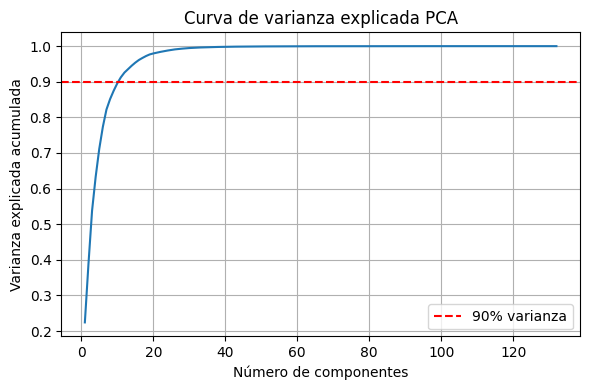

In [32]:
pca_summary_path = ARTIFACTS_PATH / 'pca_results.csv'
pca_df.to_csv(pca_summary_path, index=False)
print(f"Resultados PCA guardados en {pca_summary_path}")

plt.figure(figsize=(6, 4))
plt.plot(pca_df['n_components'], pca_df['accuracy'], marker='o', label='Accuracy')
plt.plot(pca_df['n_components'], pca_df['macro_f1'], marker='s', label='Macro F1')
plt.xlabel('Componentes PCA')
plt.ylabel('Score')
plt.title('Desempeño con PCA')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Curva de varianza explicada acumulada con todos los componentes
full_pca = PCA().fit(X_train_scaled)
cumulative_variance = np.cumsum(full_pca.explained_variance_ratio_)

plt.figure(figsize=(6, 4))
plt.plot(np.arange(1, len(cumulative_variance) + 1), cumulative_variance)
plt.axhline(0.9, color='red', linestyle='--', label='90% varianza')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada acumulada')
plt.title('Curva de varianza explicada PCA')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [33]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='accuracy', ascending=False)

results_path = ARTIFACTS_PATH / 'feature_reduction_summary.csv'
results_df.to_csv(results_path, index=False)
print(f"Resumen consolidado guardado en {results_path}")

results_df


Resumen consolidado guardado en /content/Entrega 3/artifacts/feature_reduction_summary.csv


,run,accuracy,macro_f1,classifier,n_features
20,pca_80,0.987725,0.989644,SVC_PCA,80
19,pca_60,0.987725,0.989644,SVC_PCA,60
21,pca_100,0.987342,0.989356,SVC_PCA,100
18,pca_40,0.984273,0.983390,SVC_PCA,40
0,baseline_all_features,0.982355,0.985323,RandomForestClassifier,132
5,rf_top_100_importances,0.981204,0.984215,RandomForestClassifier,100
4,rf_top_80_importances,0.980821,0.984170,RandomForestClassifier,80
3,rf_top_60_importances,0.979670,0.983305,RandomForestClassifier,60
15,mutual_info_k100,0.979287,0.982824,SVC,100
10,anova_k100,0.978903,0.981632,SVC,100
